# Chapter 4 - RNN on Amazon Stock (Scratch, Keras, PyTorch)

In [1]:
# Install required libraries
import sys
!{sys.executable} -m pip install -q numpy pandas matplotlib scikit-learn torch tensorflow yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)


## 1. Load Data

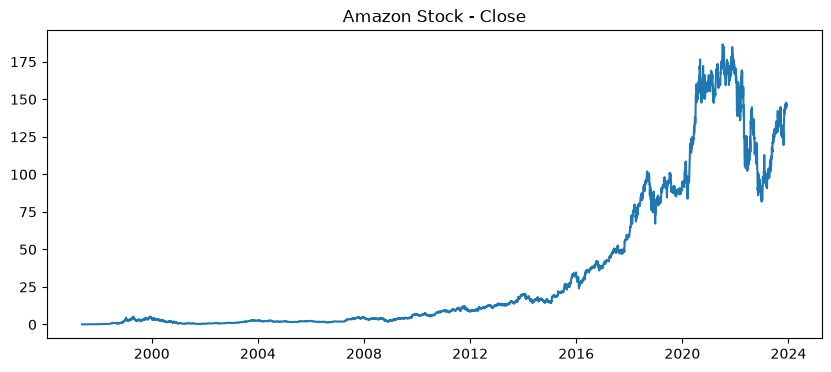

X_train shape: (5323, 30, 1)
y_train shape: (5323,)


In [3]:
df = pd.read_csv('../data/AMZN.csv')
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

df.dropna(inplace=True)

plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title('Amazon Stock - Close')
plt.show()

data = df.filter(['Close']).values
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

window_size = 30
X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


## 2. RNN from Scratch (NumPy)

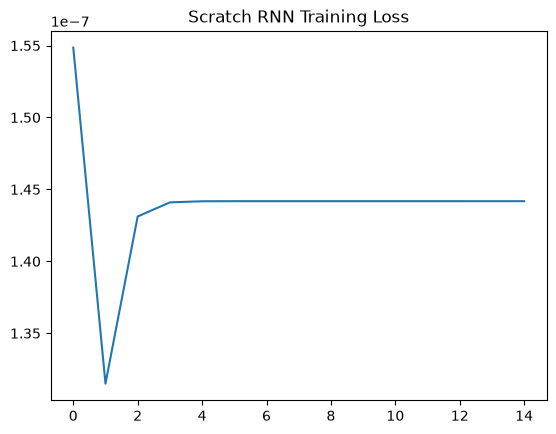

In [4]:
# Simplified RNN from scratch
class SimpleRNN_Numpy:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.Wx = np.random.randn(hidden_size, input_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))
        self.lr = learning_rate
        
    def forward(self, x):
        h = np.zeros((self.Wh.shape[0], 1))
        self.hs = {0: h}
        self.xs = {}
        for t in range(x.shape[0]):
            self.xs[t] = x[t].reshape(-1, 1)
            h = np.tanh(np.dot(self.Wx, self.xs[t]) + np.dot(self.Wh, h) + self.bh)
            self.hs[t+1] = h
        y = np.dot(self.Wy, h) + self.by
        return y
        
    def train_step(self, x, y_true):
        # Forward
        y_pred = self.forward(x)
        loss = np.mean((y_pred - y_true)**2)
        
        # Backward (simplified BPTT)
        dy = 2 * (y_pred - y_true)
        dWy = np.dot(dy, self.hs[x.shape[0]].T)
        dby = dy
        
        dh = np.dot(self.Wy.T, dy)
        dWx, dWh, dbh = np.zeros_like(self.Wx), np.zeros_like(self.Wh), np.zeros_like(self.bh)
        
        for t in reversed(range(x.shape[0])):
            dtanh = (1 - self.hs[t+1]**2) * dh
            dbh += dtanh
            dWx += np.dot(dtanh, self.xs[t].T)
            dWh += np.dot(dtanh, self.hs[t].T)
            dh = np.dot(self.Wh.T, dtanh)
            
        # Update
        for param, dparam in zip([self.Wx, self.Wh, self.Wy, self.bh, self.by], [dWx, dWh, dWy, dbh, dby]):
            param -= self.lr * np.clip(dparam, -1, 1) # gradient clipping
            
        return loss

rnn_scratch = SimpleRNN_Numpy(1, 16, 1, 0.005)
epochs = 15
history_scratch = []

for epoch in range(epochs):
    epoch_loss = 0
    # Train on a small subset for speed in this demo
    limit = min(200, len(X_train))
    for i in range(limit):
        loss = rnn_scratch.train_step(X_train[i], y_train[i])
        epoch_loss += loss
    history_scratch.append(epoch_loss / limit)

plt.plot(history_scratch)
plt.title("Scratch RNN Training Loss")
plt.show()

preds_scratch = []
for i in range(len(X_test)):
    preds_scratch.append(rnn_scratch.forward(X_test[i])[0,0])
preds_scratch = np.array(preds_scratch)


## 3. RNN with Keras/TensorFlow

C:\Users\Admin\AppData\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


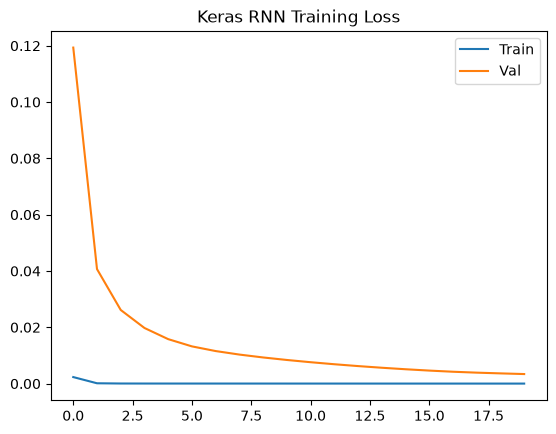

In [5]:
model_tf = Sequential([
    tf.keras.Input(shape=(window_size, 1)),
    SimpleRNN(16),
    Dense(1)
])
model_tf.compile(optimizer='adam', loss='mse')
history_tf = model_tf.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

plt.plot(history_tf.history['loss'], label='Train')
plt.plot(history_tf.history['val_loss'], label='Val')
plt.title("Keras RNN Training Loss")
plt.legend()
plt.show()

preds_tf = model_tf.predict(X_test, verbose=0).flatten()


## 4. RNN with PyTorch

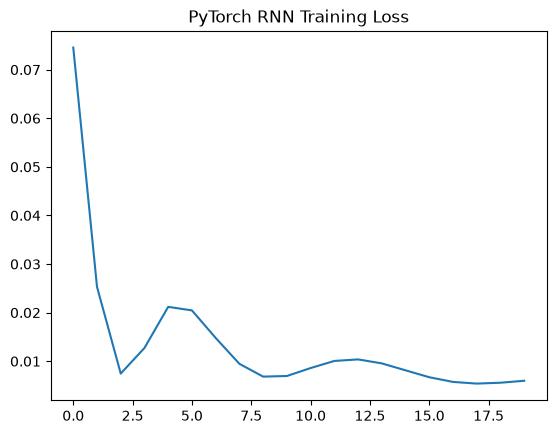

In [6]:
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_pt = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.01)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

epochs = 20
history_pt = []
for epoch in range(epochs):
    model_pt.train()
    optimizer.zero_grad()
    outputs = model_pt(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    history_pt.append(loss.item())

plt.plot(history_pt)
plt.title("PyTorch RNN Training Loss")
plt.show()

model_pt.eval()
with torch.no_grad():
    preds_pt = model_pt(X_test_t).numpy().flatten()


## 5. Comparison

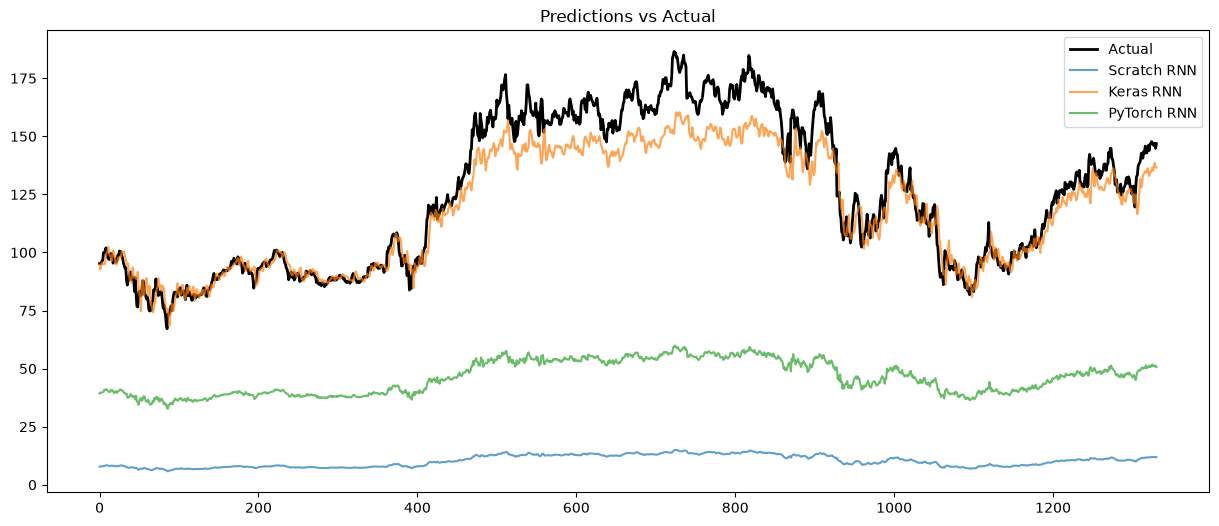

Scratch  - RMSE: 118.17239094580306 MAE: 114.45016628363078
Keras    - RMSE: 10.88190036094227 MAE: 8.14005762235389
PyTorch  - RMSE: 82.31492472513601 MAE: 78.48168345177957


In [7]:
# Inverse transform
preds_scratch_inv = scaler.inverse_transform(preds_scratch.reshape(-1, 1)).flatten()
preds_tf_inv = scaler.inverse_transform(preds_tf.reshape(-1, 1)).flatten()
preds_pt_inv = scaler.inverse_transform(preds_pt.reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(15,6))
plt.plot(y_test_inv, label="Actual", color="black", linewidth=2)
plt.plot(preds_scratch_inv, label="Scratch RNN", alpha=0.7)
plt.plot(preds_tf_inv, label="Keras RNN", alpha=0.7)
plt.plot(preds_pt_inv, label="PyTorch RNN", alpha=0.7)
plt.title("Predictions vs Actual")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Scratch  - RMSE:", np.sqrt(mean_squared_error(y_test_inv, preds_scratch_inv)), "MAE:", mean_absolute_error(y_test_inv, preds_scratch_inv))
print("Keras    - RMSE:", np.sqrt(mean_squared_error(y_test_inv, preds_tf_inv)), "MAE:", mean_absolute_error(y_test_inv, preds_tf_inv))
print("PyTorch  - RMSE:", np.sqrt(mean_squared_error(y_test_inv, preds_pt_inv)), "MAE:", mean_absolute_error(y_test_inv, preds_pt_inv))
